In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer, BertForSequenceClassification
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)
model.to(device)
model.eval()

print(f"Model: {model_name}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: bert-base-uncased
Number of layers: 12


In [ ]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2", split="train[:100000]")
texts = [item["sentence"] for item in dataset]
labels = [item["label"] for item in dataset]

print(f"Class distribution in SST-2:")
print(f"  Positive: {sum(labels)}, Negative: {len(labels)-sum(labels)}")

Class distribution in SST-2:
  Positive: 37569, Negative: 29780


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"\nTrain size: {len(train_texts)}, Val size: {len(val_texts)}")
print(f"Train class distribution: Positive={sum(train_labels)}, Negative={len(train_labels)-sum(train_labels)}")
print(f"Val class distribution: Positive={sum(val_labels)}, Negative={len(val_labels)-sum(val_labels)}")


Train size: 53879, Val size: 13470
Train class distribution: Positive=30055, Negative=23824
Val class distribution: Positive=7514, Negative=5956


In [ ]:
def extract_all_layer_embeddings(texts, model, tokenizer, device, batch_size=8):
    model.eval()
    all_layer_embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt",
                              padding=True, truncation=True, max_length=128)
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            hidden_states = outputs.hidden_states

            batch_layer_embs = []
            for layer_state in hidden_states:
                cls_emb = layer_state[:, 0, :].cpu().numpy()
                batch_layer_embs.append(cls_emb)

            all_layer_embeddings.append(batch_layer_embs)

    n_layers = len(hidden_states)
    n_samples = len(texts)
    hidden_dim = hidden_states[0].shape[-1]

    embeddings_by_layer = np.zeros((n_layers, n_samples, hidden_dim))

    for batch_idx, batch_embs in enumerate(all_layer_embeddings):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        for layer_idx in range(n_layers):
            if layer_idx < len(batch_embs):
                embeddings_by_layer[layer_idx, start_idx:end_idx, :] = batch_embs[layer_idx]

    return embeddings_by_layer

train_embeddings_by_layer = extract_all_layer_embeddings(
    train_texts, model, tokenizer, device, batch_size=8
)

val_embeddings_by_layer = extract_all_layer_embeddings(
    val_texts, model, tokenizer, device, batch_size=8
)

Extracting embeddings: 100%|██████████| 1684/1684 [00:30<00:00, 55.28it/s]


In [ ]:
def train_evaluate_for_layers(train_embs, train_labels, val_embs, val_labels):
    results = []
    n_layers = train_embs.shape[0]
    train_labels = np.array(train_labels)
    val_labels = np.array(val_labels)

    for layer_idx in range(n_layers):
        X_train = train_embs[layer_idx]
        X_val = val_embs[layer_idx]

        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        clf.fit(X_train, train_labels)

        y_pred = clf.predict(X_val)

        acc = accuracy_score(val_labels, y_pred)
        f1 = f1_score(val_labels, y_pred, average='binary')
        precision = precision_score(val_labels, y_pred, average='binary')
        recall = recall_score(val_labels, y_pred, average='binary')

        layer_name = 'embedding' if layer_idx == 0 else f'layer_{layer_idx-1}'

        results.append({
            'layer': int(layer_idx),
            'layer_name': layer_name,
            'accuracy': acc,
            'f1_score': f1,
            'precision': precision,
            'recall': recall
        })

        print(f"  Layer {layer_idx} ({layer_name}): Acc={acc:.4f}, F1={f1:.4f}")

    return pd.DataFrame(results)

results_df = train_evaluate_for_layers(
    train_embeddings_by_layer, train_labels,
    val_embeddings_by_layer, val_labels
)

  Layer 0 (embedding): Acc=0.5578, F1=0.7162
  Layer 1 (layer_0): Acc=0.8177, F1=0.8381
  Layer 2 (layer_1): Acc=0.8220, F1=0.8417
  Layer 3 (layer_2): Acc=0.8270, F1=0.8456
  Layer 4 (layer_3): Acc=0.8269, F1=0.8451
  Layer 5 (layer_4): Acc=0.8287, F1=0.8467
  Layer 6 (layer_5): Acc=0.8399, F1=0.8568
  Layer 7 (layer_6): Acc=0.8400, F1=0.8571
  Layer 8 (layer_7): Acc=0.8488, F1=0.8649
  Layer 9 (layer_8): Acc=0.8617, F1=0.8765
  Layer 10 (layer_9): Acc=0.8665, F1=0.8808
  Layer 11 (layer_10): Acc=0.8683, F1=0.8820
  Layer 12 (layer_11): Acc=0.8696, F1=0.8837


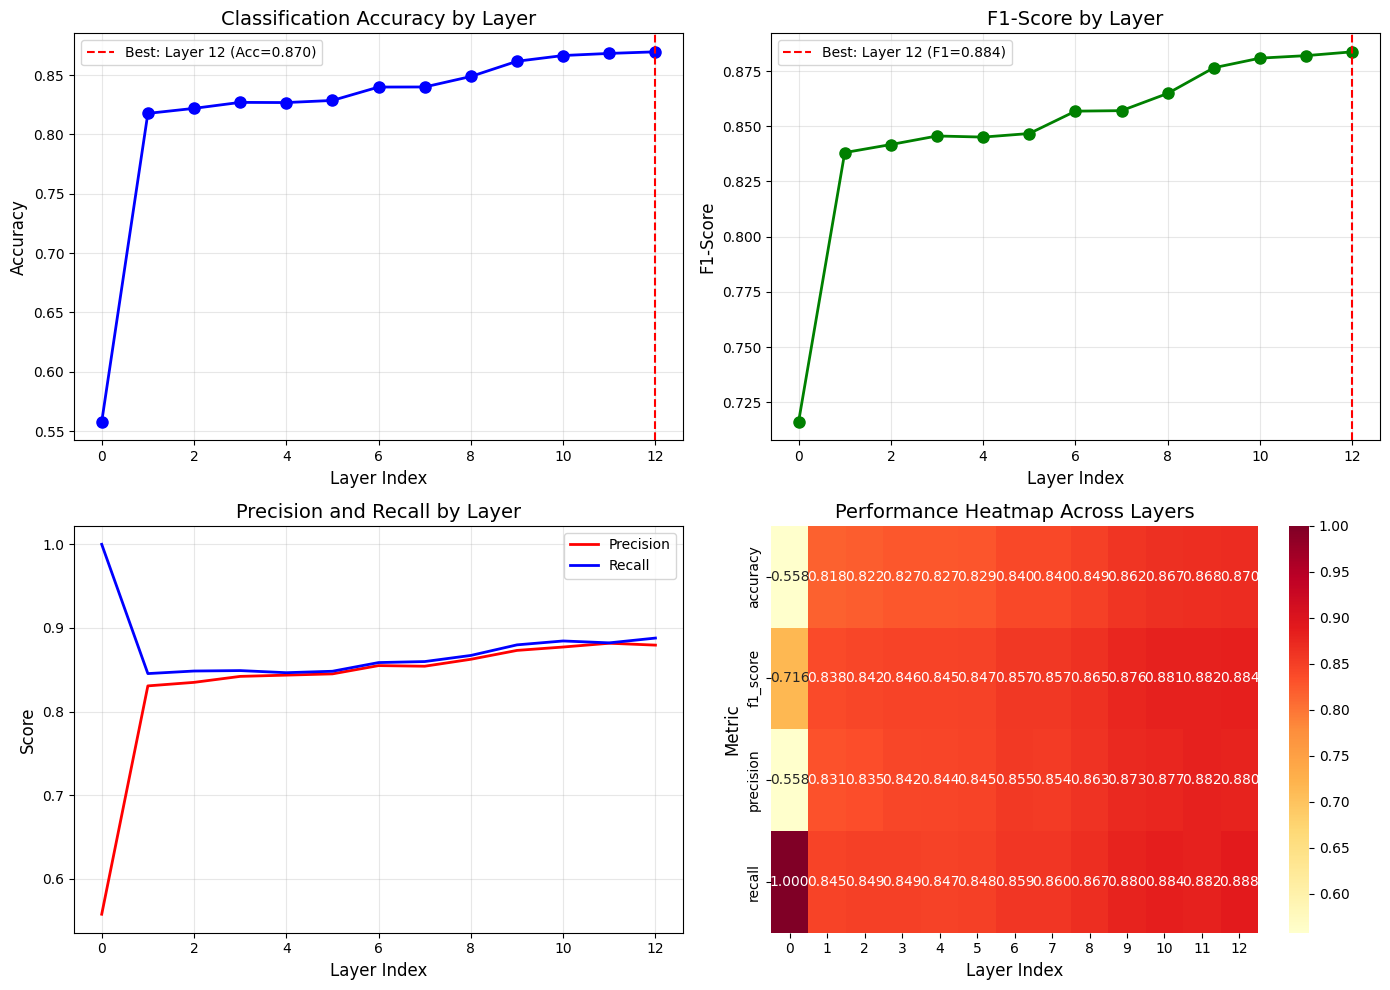

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

layer_indices = results_df['layer'].values

axes[0, 0].plot(layer_indices, results_df['accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Layer Index', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Classification Accuracy by Layer', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
best_acc_idx = results_df['accuracy'].idxmax()
best_acc_layer = results_df.loc[best_acc_idx, 'layer']
axes[0, 0].axvline(x=best_acc_layer, color='red', linestyle='--',
                   label=f"Best: Layer {best_acc_layer} (Acc={results_df.loc[best_acc_idx, 'accuracy']:.3f})")
axes[0, 0].legend()

axes[0, 1].plot(layer_indices, results_df['f1_score'], 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Layer Index', fontsize=12)
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score by Layer', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)
best_f1_idx = results_df['f1_score'].idxmax()
best_f1_layer = results_df.loc[best_f1_idx, 'layer']
axes[0, 1].axvline(x=best_f1_layer, color='red', linestyle='--',
                   label=f"Best: Layer {best_f1_layer} (F1={results_df.loc[best_f1_idx, 'f1_score']:.3f})")
axes[0, 1].legend()

axes[1, 0].plot(layer_indices, results_df['precision'], 'r-', linewidth=2, markersize=8, label='Precision')
axes[1, 0].plot(layer_indices, results_df['recall'], 'b-', linewidth=2, markersize=8, label='Recall')
axes[1, 0].set_xlabel('Layer Index', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Precision and Recall by Layer', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

metrics_to_plot = ['accuracy', 'f1_score', 'precision', 'recall']
heatmap_data = results_df[metrics_to_plot].T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1, 1],
            xticklabels=layer_indices)
axes[1, 1].set_xlabel('Layer Index', fontsize=12)
axes[1, 1].set_ylabel('Metric', fontsize=12)
axes[1, 1].set_title('Performance Heatmap Across Layers', fontsize=14)

plt.tight_layout()
plt.savefig('layer_performance.png', dpi=150, bbox_inches='tight')
plt.show()

`Разделимость = (Расстояние между центроидами) / (Среднее внутриклассовое расстояние)`

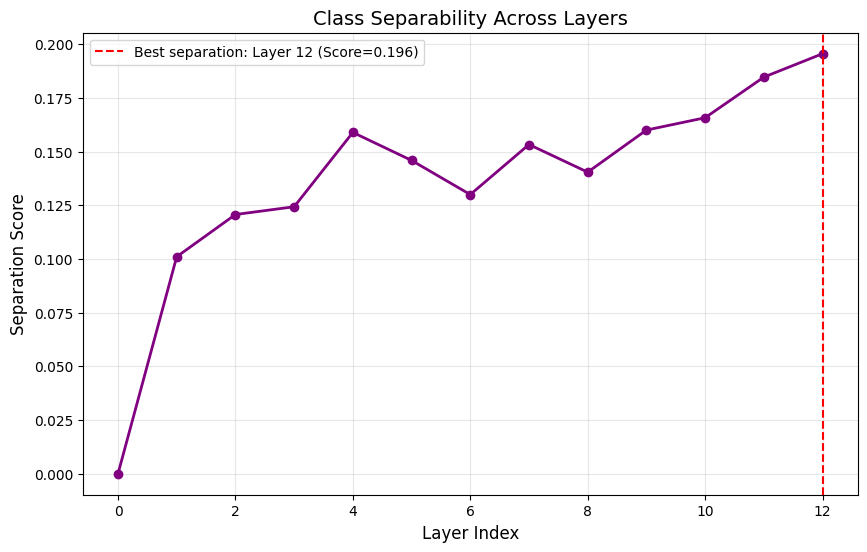

In [ ]:
def compute_separation_metric(embeddings, labels):
    embeddings = np.array(embeddings)
    labels = np.array(labels)

    pos_center = embeddings[labels == 1].mean(axis=0)
    neg_center = embeddings[labels == 0].mean(axis=0)

    between_class_dist = np.linalg.norm(pos_center - neg_center)

    within_pos = np.mean([np.linalg.norm(x - pos_center) for x in embeddings[labels == 1]])
    within_neg = np.mean([np.linalg.norm(x - neg_center) for x in embeddings[labels == 0]])
    within_class_dist = (within_pos + within_neg) / 2

    separation = between_class_dist / (within_class_dist + 1e-8)
    return separation

separation_scores = []
for layer_idx in range(train_embeddings_by_layer.shape[0]):
    sep = compute_separation_metric(train_embeddings_by_layer[layer_idx], train_labels)
    separation_scores.append(sep)

plt.figure(figsize=(10, 6))
plt.plot(range(len(separation_scores)), separation_scores, 'purple', linewidth=2, marker='o')
plt.xlabel('Layer Index', fontsize=12)
plt.ylabel('Separation Score', fontsize=12)
plt.title('Class Separability Across Layers', fontsize=14)
plt.grid(True, alpha=0.3)
best_sep_layer = np.argmax(separation_scores)
plt.axvline(x=best_sep_layer, color='red', linestyle='--',
           label=f"Best separation: Layer {best_sep_layer} (Score={separation_scores[best_sep_layer]:.3f})")
plt.legend()
plt.savefig('separability.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
summary_table = results_df.copy()
summary_table['separation_score'] = separation_scores[:len(results_df)]
summary_table = summary_table.round(4)

print(f"\nTop-3 layers by Accuracy:")
print(results_df.nlargest(3, 'accuracy')[['layer', 'layer_name', 'accuracy']])
print(f"\nTop-3 layers by F1-score:")
print(results_df.nlargest(3, 'f1_score')[['layer', 'layer_name', 'f1_score']])

early_avg = results_df[results_df['layer'] <= 3]['f1_score'].mean()
mid_avg = results_df[(results_df['layer'] >= 4) & (results_df['layer'] <= 8)]['f1_score'].mean()
late_avg = results_df[results_df['layer'] >= 9]['f1_score'].mean()

print(f"Average F1-scores by layer groups:")
print(f"  Early layers (0-3):     {early_avg:.4f}")
print(f"  Middle layers (4-8):    {mid_avg:.4f}")
print(f"  Late layers (9-12):     {late_avg:.4f}")


Top-3 layers by Accuracy:
    layer layer_name  accuracy
12     12   layer_11  0.869636
11     11   layer_10  0.868300
10     10    layer_9  0.866518

Top-3 layers by F1-score:
    layer layer_name  f1_score
12     12   layer_11  0.883709
11     11   layer_10  0.881985
10     10    layer_9  0.880848
Average F1-scores by layer groups:
  Early layers (0-3):     0.8104
  Middle layers (4-8):    0.8541
  Late layers (9-12):     0.8808


**Вывод**

В ходе работы были проанализированы эмбеддинги всех слоев для задачи классификации тональности SST-2.

1.  **Производительность классификации:** Наблюдается четкий восходящий тренд метрик (Accuracy, F1-score, Precision, Recall) по мере движения от первого слоя к последнему (с 0.56 до 0.87). Наилучшие результаты демонстрирует последний скрытый слой (слой 11). Промежуточные слои (с 4 по 8) дают стабильные, но все же более низкие результаты, чем финальные.

2.  **Разделимость:** График разделимости демонстрирует, что классы практически неразличимы на уровне эмбеддингов (слой 0), но их центроиды стремительно расходятся по мере углубления в сеть. Пик разделимости также приходится на последние слои, что коррелирует с ростом точности классификации.


**Общее заключение:** Для извлечения классификационных признаков из BERT предпочтительно использовать эмбеддинги последних слоев (`layer_10`, `layer_11`).